In [60]:
import numpy as np
import matplotlib.pyplot as plt


**Caso de tarjeta de credito**

Identificar si una persona puede tener tarjeta de credito en base al indice de crédito y ahorro

In [ ]:
#Datos de 10 personas [crédito, ahorro]
personas= np.array([[0.3,0.4],[0.4,0.3],
                    [0.3,0.2],[0.4,0.1],
                    [0.5,0.2],[0.4,0.8],
                    [0.6,0.8],[0.5,0.6],
                    [0.7,0.6],[0.8,0.5]])


In [ ]:
#1: aprobado , 0:desaprobado
clases= np.array([0,0,0,0,0,1,1,1,1,1])

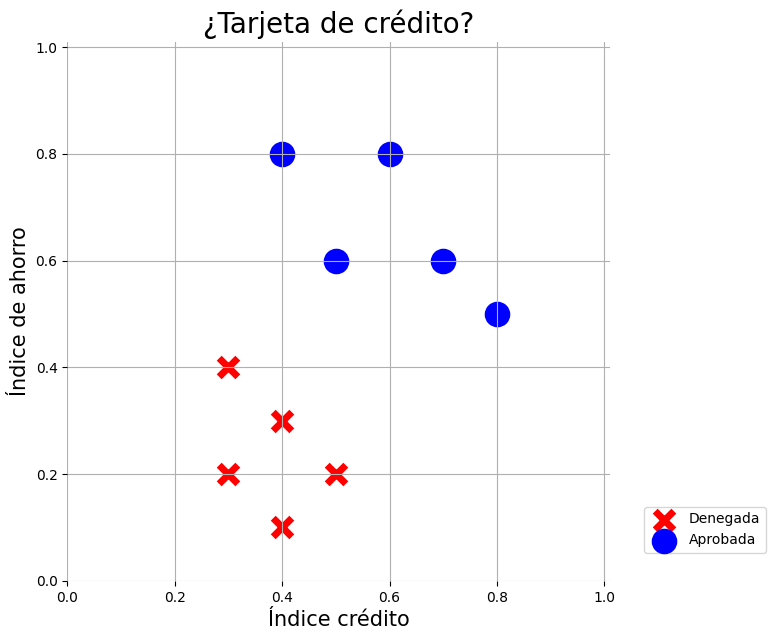

In [ ]:
# Gráfica de dispersión (índice crédito, índice de ahorro)
plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta de crédito?", fontsize=20)
plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")
plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")
plt.xlabel("Índice crédito", fontsize=15)
plt.ylabel("Índice de ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()

In [ ]:
# xl*w1+x2*w2
#x datos de indice de credito y=ahorro
def activation(x,pesos,b):
  z=pesos*x
  if np.sum(z)+b>0:
    return 1
  else:
    return 0
  return z


In [ ]:
pesos=np.random.uniform(-1,1,size=2)
b=np.random.uniform(-1,1)
print(pesos)
print(b)

[-0.70060265  0.5619132 ]
-0.2634695001295526


Implementacion de arquitectura de perceptrón

In [ ]:
pesos=np.random.uniform(-1,1,size=2)
b=np.random.uniform(-1,1)
epocas = 100
tasa_de_aprobacion= 0.01
for epoca in range(epocas):
  error_total=0
  for i in range(len(personas)):
    prediction=activation(personas[i],pesos,b)
    error= clases[i]-prediction
    error_total=error**2
    pesos[0] = pesos[0] + tasa_de_aprobacion * error * personas[i][0]
    pesos[1] = pesos[1] + tasa_de_aprobacion * error * personas[i][1]
    b=b+tasa_de_aprobacion*error
  print(error_total,end="")
activation([0.7,0.8],pesos,b)


1111111111111111111011111110111111101111111011111111011111111111111111111111111111111111100111011100

1

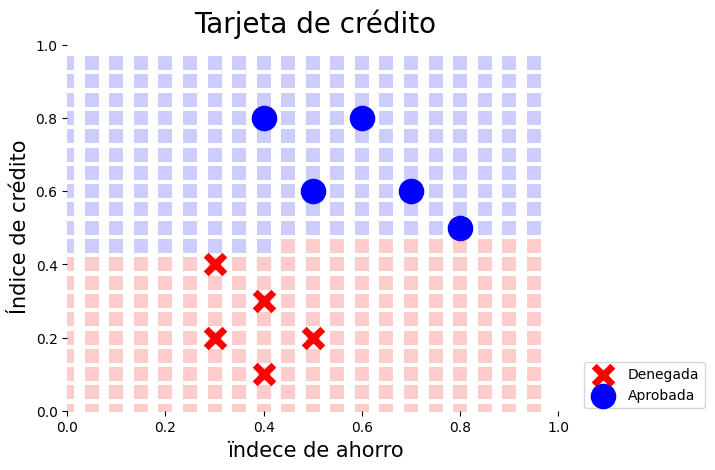

In [ ]:
plt.title("Tarjeta de crédito", fontsize=20)

plt.scatter(personas[clases == 0].T[0],
            personas[clases == 0].T[1],
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")

plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1],
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")

for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        color = activation(pesos, [edad, ahorro], b)
        if color == 1:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="blue", alpha=0.2, linewidths=0)
        else:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="red", alpha=0.2, linewidths=0)

plt.xlabel("ïndece de ahorro", fontsize=15)
plt.ylabel("Índice de crédito", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()

Arquitectura con Perceptron de SK_Learn

In [ ]:
from sklearn.linear_model import Perceptron
perceptron= Perceptron()
perceptron.fit(personas,clases)
perceptron.predict([[0.2,0.2],[0.8,0.8]])


array([0, 1])

Función Tangente hiperbolica

In [151]:
import numpy as np
import matplotlib.pyplot as plt
# Calificación 2.5/10, 1000 reseñas → MALA
peliculas = np.array([
    [0.25, 0.1],
    [0.36, 0.5],
    [0.39, 0.2],
    [0.43, 0.3],
    [0.48, 0.1],
    [0.77, 0.7],
    [0.88, 0.8],
    [0.86, 0.7],
    [0.97, 0.9],
    [0.89, 0.9]
])


clasificacion = np.array([-1, -1, -1, -1, -1, 1, 1, 1, 1, 1])

def activationTanh(x, pesos, b):
    z = pesos * x
    suma = np.sum(z) + b
    return (1 - np.exp(-suma)) / (1 + np.exp(-suma))

def tanh_derivative(output):
    return 1 - output**2

pesosTanh = np.random.uniform(-1, 1, size=2)
bTanh = np.random.uniform(-1, 1)

epocas = 1500
tasa_de_aprendizaje = 0.05

for epoca in range(epocas):
    error_total = 0
    for i in range(len(peliculas)):
        prediction = activationTanh(peliculas[i], pesosTanh, bTanh)
        error = clasificacion[i] - prediction
        error_total += error**2

        delta = error * tanh_derivative(prediction)
        pesosTanh[0] += tasa_de_aprendizaje * error * peliculas[i][0]
        pesosTanh[1] += tasa_de_aprendizaje * error * peliculas[i][1]
        bTanh += tasa_de_aprendizaje * error
    #print(error_total,end="")

# ========================================
# PRUEBAS
# ========================================

casos_prueba = [
    ([0.25, 0.1]),
    ([0.50, 0.5]),
    ([0.70, 0.8]),
    ([0.90, 0.9])
]
for datos in casos_prueba:
    pred = activationTanh(datos, pesosTanh, bTanh)
    clase = 1 if pred > 0 else -1
    resultado = "RECOMENDADA" if clase == 1 else "NO RECOMENDADA"
    print(f"  Predicción tanh: {pred:.4f}")
    print(f" Resultado: {resultado}")




  Predicción tanh: -0.9990
 Resultado: NO RECOMENDADA
  Predicción tanh: -0.6080
 Resultado: NO RECOMENDADA
  Predicción tanh: 0.9343
 Resultado: RECOMENDADA
  Predicción tanh: 0.9965
 Resultado: RECOMENDADA


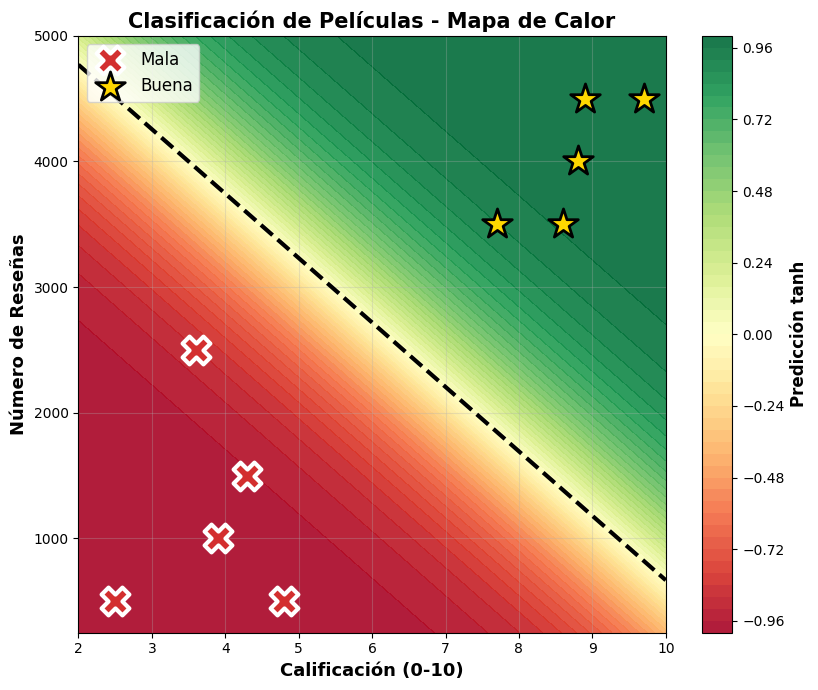

In [149]:
plt.figure(figsize=(16, 7))

# Crear malla
calif = np.linspace(0.2, 1.0, 150)
reseñas = np.linspace(0.05, 1.0, 150)
C, R = np.meshgrid(calif, reseñas)

# Predicciones
Z = np.zeros_like(C)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        Z[i, j] = activationTanh([C[i, j], R[i, j]], pesosTanh, bTanh)

# ========== SUBPLOT 1: Mapa de calor ==========
plt.subplot(1, 2, 1)
heatmap = plt.contourf(C * 10, R * 5000, Z, levels=50,
                       cmap='RdYlGn', alpha=0.9)
cbar = plt.colorbar(heatmap, label='Predicción tanh')
cbar.set_label('Predicción tanh', fontsize=12, fontweight='bold')

# Línea de decisión
plt.contour(C * 10, R * 5000, Z, levels=[0],
            colors='black', linewidths=3, linestyles='--')

# Plotear películas
plt.scatter(peliculas[clasificacion == -1][:, 0] * 10,
            peliculas[clasificacion == -1][:, 1] * 5000,
            marker='X', s=400, color='#d32f2f',
            linewidths=3, label='Mala',
            edgecolors='white', zorder=5)

plt.scatter(peliculas[clasificacion == 1][:, 0] * 10,
            peliculas[clasificacion == 1][:, 1] * 5000,
            marker='*', s=500, color='#ffd700',
            linewidths=2, label='Buena',
            edgecolors='black', zorder=5)

plt.xlabel('Calificación (0-10)', fontsize=13, fontweight='bold')
plt.ylabel('Número de Reseñas', fontsize=13, fontweight='bold')
plt.title('Clasificación de Películas - Mapa de Calor',
          fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

In [159]:
from sklearn.linear_model import Perceptron
perceptronTanh= Perceptron()
perceptronTanh.fit(peliculas,clasificacion)
perceptronTanh.predict([[0.25, 0.9],[0.63,0.7]])

array([-1,  1])